### K-fold

It's a combination of train and validation operation. No prediction is performed. For each hyperpar an entire K-fold algorithm is run. At each fold we have a score. Score average gives a robust estimate of the model performance. Perform k-fold for n values of hyperparameters using GridSearchCV. 

## Gamma Ray Bursts

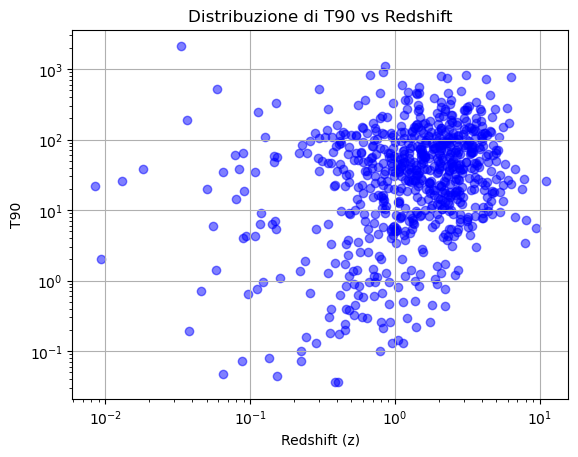

In [6]:
import requests
import numpy as np
import matplotlib.pyplot as plt

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

ra = data[3,:].astype(float)
dec = data[4,:].astype(float)
T90 = data[6,:].astype(float)
flux = data[9,:].astype(float)
err_flux = data[10,:].astype(float)
z = data[11,:].astype(float)

mask = (z != -999) & (T90 != -999)

flux_pulito = flux[mask]
T90_pulito = T90[mask]
ra_pulito = ra[mask]
dec_pulito = dec[mask]
z_pulito = z[mask]

plt.scatter(z_pulito, T90_pulito, alpha=0.5, color='blue')
plt.xlabel('Redshift (z)')
plt.ylabel('T90')
plt.title('Distribuzione di T90 vs Redshift')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()


### Kmeans

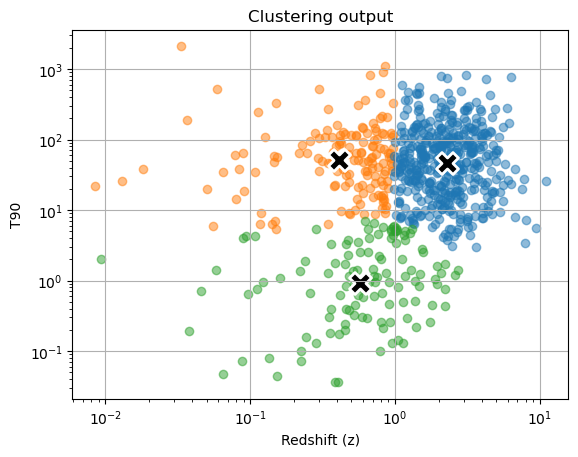

In [7]:
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

X = np.column_stack((z_pulito, T90_pulito))
X_log = np.log10(X + 1e-10)
scaler = StandardScaler()

clf = KMeans(n_clusters=3,n_init='auto')
clf.fit(scaler.fit_transform(X_log))
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(scaler.fit_transform(X_log)) #labels for each of the points

colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.5)
    
centri_scalati = clf.cluster_centers_
centri_log = scaler.inverse_transform(centri_scalati)
centri_fisici = (10 ** centri_log) - 1e-10

plt.scatter(centri_fisici[:, 0], centri_fisici[:, 1], 
            marker='X', s=250, color='black', edgecolors='white', 
            linewidths=2, label='Centroidi (MLE)')

plt.xlabel('Redshift (z)')
plt.ylabel('T90')
plt.title('Distribuzione di T90 vs Redshift')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.title('Clustering output')
plt.show()

### MeanShift

6


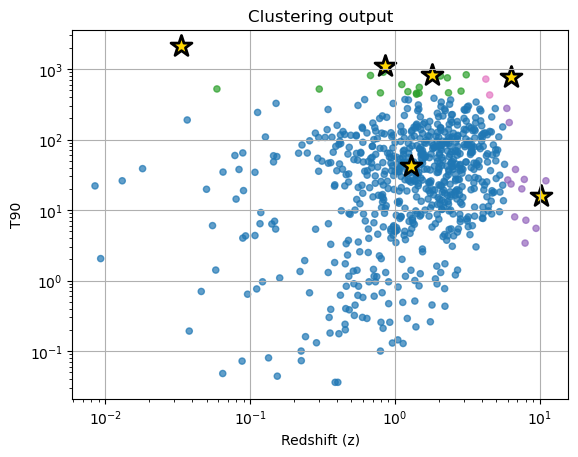

In [8]:
# Compute the Mean-shift clustering
from sklearn.cluster import MeanShift

scaler = preprocessing.StandardScaler()
ms = MeanShift(bandwidth=1.2,
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform(X))

centri_scalati_ms = ms.cluster_centers_
centri_fisici_ms = scaler.inverse_transform(centri_scalati_ms)
print(len(centri_fisici_ms))

plt.scatter(z_pulito,T90_pulito,c=ms.predict(scaler.fit_transform(X)),cmap='tab10',s=20,alpha=0.7)
    
plt.scatter(centri_fisici_ms[:, 0], centri_fisici_ms[:, 1], 
            marker='*', s=250, color='gold', edgecolors='black', 
            linewidths=2, label='Centroidi (MLE)')

plt.xlabel('Redshift (z)')
plt.ylabel('T90')
plt.title('Distribuzione di T90 vs Redshift')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.title('Clustering output')
plt.show()